Mounted at /content/drive
Extracting /content/drive/MyDrive/mango_dataset/MangoOriginal.zip ...
Extracting /content/drive/MyDrive/mango_dataset/MangoAugmented.zip ...
Extracting /content/drive/MyDrive/mango_dataset/MangoRealVirtual.zip ...
Extraction complete!
 Amrapali	    'Banana Mango'  'Fazli Classic'   Harivanga   Langra
'Ashshina Classic'   Bari-11	    'Fazli Shurmai'   Himsagor	  Rupali
'Ashshina Zhinuk'    Bari-4	     Gourmoti	      Katimon	  Shada
Class found: Amrapali — 675 images
Class found: Katimon — 2120 images
Class found: Shada — 815 images
Class found: Bari-4 — 370 images
Class found: Ashshina_Zhinuk — 6430 images
Class found: Harivanga — 1325 images
Class found: Bari-11 — 6220 images
Class found: Fazli_Shurmai — 1235 images
Class found: Banana_Mango — 415 images
Class found: Rupali — 920 images
Class found: Himsagor — 530 images
Class found: Fazli_Classic — 855 images
Class found: Langra — 600 images
Class found: Ashshina_Classic — 2855 images
Class found: Gourmoti — 

Training:   0%|          | 0/713 [00:00<?, ?it/s]

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Train Acc=0.742 | Val Acc=0.833
Train Loss=0.797 | Val Loss=0.493

Epoch 2/7


Training:   0%|          | 0/713 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Train Acc=0.959 | Val Acc=0.944
Train Loss=0.121 | Val Loss=0.160

Epoch 7/7


Training:   0%|          | 0/713 [00:00<?, ?it/s]

Validating:   0%|          | 0/179 [00:00<?, ?it/s]

Train Acc=0.969 | Val Acc=0.487
Train Loss=0.094 | Val Loss=3.954


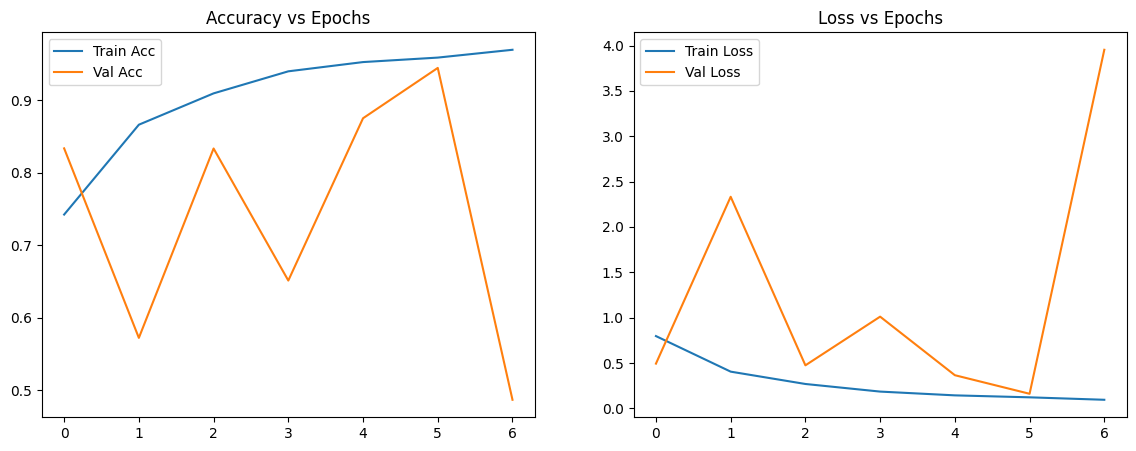

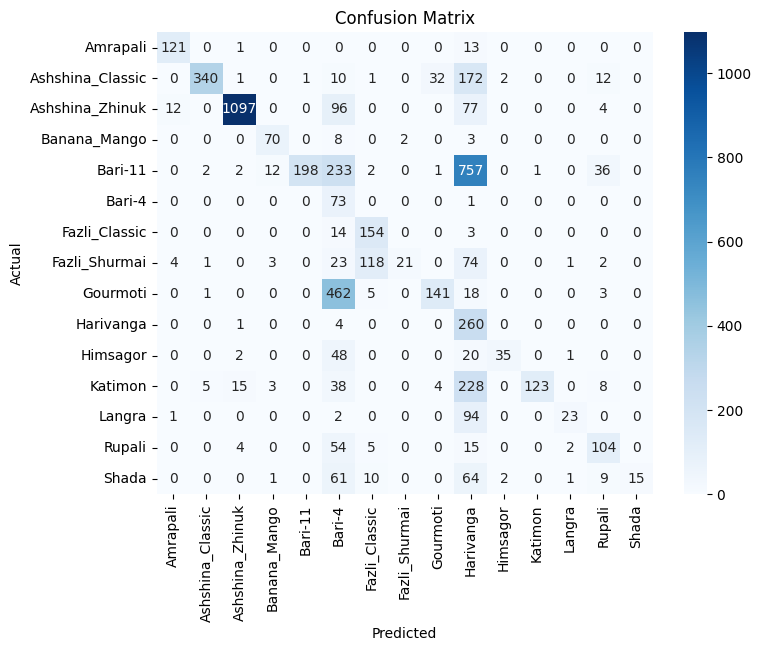

In [ ]:
import shutil, os

for folder in ["/content/mango_raw", "/content/mango_combined", "/content/mango_split"]:
    if os.path.exists(folder):
        shutil.rmtree(folder)


from google.colab import drive
drive.mount('/content/drive')

ZIP_DIR = "/content/drive/MyDrive/mango_dataset"
ZIP_FILES = {
    "MangoOriginal.zip":     f"{ZIP_DIR}/MangoOriginal.zip",
    "MangoAugmented.zip":    f"{ZIP_DIR}/MangoAugmented.zip",
    "MangoRealVirtual.zip":  f"{ZIP_DIR}/MangoRealVirtual.zip",
}

os.makedirs("/content/mango_raw", exist_ok=True)


import zipfile

for name, path in ZIP_FILES.items():
    if os.path.exists(path):
        print(f"Extracting {path} ...")
        with zipfile.ZipFile(path, "r") as z:
            z.extractall("/content/mango_raw")

print("Extraction complete!")
!ls /content/mango_raw


#flatten
combined_root = "/content/mango_combined"
os.makedirs(combined_root, exist_ok=True)

def extract_class_folders(src_root, dest_root):
    import os, shutil
    exts = ('.jpg','.jpeg','.png','.webp','.bmp')

    for root, dirs, files in os.walk(src_root):
        images = [f for f in files if f.lower().endswith(exts)]
        if len(images) > 0:

            class_name = os.path.basename(root).replace(" ", "_").replace("'", "")
            class_dest = os.path.join(dest_root, class_name)
            os.makedirs(class_dest, exist_ok=True)

            for img in images:
                shutil.copy(os.path.join(root, img), os.path.join(class_dest, img))

            print(f"Class found: {class_name} — {len(images)} images")

extract_class_folders("/content/mango_raw", combined_root)

print("\nFlatten complete!")
!ls /content/mango_combined


import random

split_root = "/content/mango_split"
train_dir = f"{split_root}/train"
val_dir   = f"{split_root}/val"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(combined_root):

    class_path = os.path.join(combined_root, class_name)
    if not os.path.isdir(class_path):
        continue

    imgs = os.listdir(class_path)
    random.shuffle(imgs)

    split = int(0.8 * len(imgs))

    train_imgs = imgs[:split]
    val_imgs   = imgs[split:]

    os.makedirs(f"{train_dir}/{class_name}", exist_ok=True)
    os.makedirs(f"{val_dir}/{class_name}", exist_ok=True)

    import shutil

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img), f"{train_dir}/{class_name}/{img}")

    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img), f"{val_dir}/{class_name}/{img}")

print("\nTrain/Val split created!")
!ls /content/mango_split/train


import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

def load_data(root):
    train_ds = datasets.ImageFolder(f"{root}/train", train_tf)
    val_ds   = datasets.ImageFolder(f"{root}/val", val_tf)
    return (
        DataLoader(train_ds, batch_size=32, shuffle=True),
        DataLoader(val_ds, batch_size=32, shuffle=False),
        len(train_ds.classes),
        train_ds.classes
    )

train_loader, val_loader, num_classes, class_names = load_data("/content/mango_split")
print("Classes:", class_names)


import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return torch.relu(self.bn(self.pw(self.dw(x))))

class ResidualDownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.c1 = ConvBlock(in_ch, out_ch, 2)
        self.c2 = ConvBlock(out_ch, out_ch)
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, 2, bias=False),
            nn.BatchNorm2d(out_ch)
        )
    def forward(self, x):
        return torch.relu(self.c2(self.c1(x)) + self.skip(x))

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 32),
            nn.MaxPool2d(2),
        )
        self.s1 = ResidualDownBlock(32, 64)
        self.s2 = nn.Sequential(
            DepthwiseSeparableBlock(64, 128, 2),
            ConvBlock(128, 128)
        )
        self.s3 = nn.Sequential(
            DepthwiseSeparableBlock(128, 256, 2),
            ConvBlock(256, 256)
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.s1(x)
        x = self.s2(x)
        x = self.s3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


model = CNN(num_classes).to(device)


import torch.optim as optim
criterion = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=1e-3)

from tqdm.notebook import tqdm

train_acc_hist, val_acc_hist = [], []
train_loss_hist, val_loss_hist = [], []


def train_one_epoch(model, loader):
    model.train()
    total, correct, loss_sum = 0, 0, 0

    for x, y in tqdm(loader, desc="Training", leave=False):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        opt.step()

        loss_sum += loss.item()
        correct  += (pred.argmax(1) == y).sum().item()
        total    += y.size(0)

    return loss_sum / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Validating", leave=False):
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)

            loss_sum += loss.item()
            correct  += (pred.argmax(1) == y).sum().item()
            total    += y.size(0)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.argmax(1).cpu().numpy())

    return loss_sum / len(loader), correct / total, y_true, y_pred


EPOCHS = 7

for epoch in range(1, EPOCHS+1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    t_loss, t_acc = train_one_epoch(model, train_loader)
    v_loss, v_acc, y_true, y_pred = evaluate(model, val_loader)

    train_acc_hist.append(t_acc)
    val_acc_hist.append(v_acc)
    train_loss_hist.append(t_loss)
    val_loss_hist.append(v_loss)

    print(f"Train Acc={t_acc:.3f} | Val Acc={v_acc:.3f}")
    print(f"Train Loss={t_loss:.3f} | Val Loss={v_loss:.3f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.title("Loss vs Epochs")
plt.legend()

plt.show()


from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()